# Spatial2D inference resource monitor

Use this notebook to inspect CPU/GPU resource monitor files produced by `scripts/inference_spatial2D.sh`.

Input a Slurm job id, then run all cells. The notebook searches for `resource_usage_<job_id>.csv`, summarizes hardware utilization, and visualizes CPU, GPU, memory, and power over time. If the matching Slurm `.out` file is available, it also parses generation-level inference progress.

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rootutils

rootutils.setup_root(Path.cwd(), indicator=".project-root", pythonpath=True)

PROJECT_ROOT = Path(rootutils.find_root(Path.cwd(), indicator=".project-root"))
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
# Input: change only this for normal use.
JOB_ID = "10220846"

# Optional search roots. Keep the project-local and cluster storage roots here
# so the same notebook works for manual runs and Slurm jobs.
USER = "kz2537"
SEARCH_ROOTS = [
    PROJECT_ROOT / "run",
    Path(f"/insomnia001/depts/iicd/users/{USER}/viaABC/run"),
    Path(f"/insomnia001/depts/iicd/users/{USER}/viaABC"),
]

JOB_ID = str(JOB_ID).strip()
if not JOB_ID:
    raise ValueError("Set JOB_ID before running the notebook.")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("JOB_ID:", JOB_ID)


PROJECT_ROOT: /insomnia001/home/kz2537/viaABC
JOB_ID: 10220846


In [3]:
def find_monitor_file(job_id: str, search_roots: list[Path]) -> Path:
    pattern = f"resource_usage_{job_id}.csv"
    matches: list[Path] = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.rglob(pattern))

    unique_matches = sorted(set(matches), key=lambda p: p.stat().st_mtime, reverse=True)
    if not unique_matches:
        searched = "\n".join(str(root) for root in search_roots)
        raise FileNotFoundError(f"Could not find {pattern}. Searched:\n{searched}")

    if len(unique_matches) > 1:
        print("Multiple monitor files found; using the newest one:")
        for path in unique_matches:
            print("  ", path)
    return unique_matches[0]


def find_slurm_out(job_id: str, monitor_path: Path, search_roots: list[Path]) -> Path | None:
    candidates: list[Path] = []
    candidate_roots = [monitor_path.parents[2] / "slurm"] if len(monitor_path.parents) > 2 else []
    candidate_roots.extend(search_roots)
    for root in candidate_roots:
        if root.exists():
            candidates.extend(root.rglob(f"*{job_id}.out"))
            candidates.extend(root.rglob(f"*{job_id}*.out"))
    candidates = sorted(set(candidates), key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0] if candidates else None


def load_monitor_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, skipinitialspace=True)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    numeric_columns = [column for column in df.columns if column != "timestamp" and column != "gpu_name"]
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")
    df = df.sort_values("timestamp").reset_index(drop=True)
    df["elapsed_minutes"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds() / 60
    df["elapsed_hours"] = df["elapsed_minutes"] / 60
    return df


def parse_generation_log(path: Path | None) -> pd.DataFrame:
    if path is None or not path.exists():
        return pd.DataFrame()

    rows = []
    pending: dict[str, float | int] = {}
    current_generation: int | None = None
    generation_pattern = re.compile(r"Generation (\d+) completed in ([0-9.]+) seconds")
    value_pattern = re.compile(r"- (Epsilon|Quantile|Simulations) : ([0-9.eE+-]+)")

    for line in path.read_text(errors="replace").splitlines():
        value_match = value_pattern.search(line)
        if value_match:
            key, value = value_match.groups()
            normalized_key = key.lower()
            pending[normalized_key] = int(float(value)) if normalized_key == "simulations" else float(value)
            continue

        generation_match = generation_pattern.search(line)
        if generation_match:
            current_generation = int(generation_match.group(1))
            pending["generation"] = current_generation
            pending["duration_seconds"] = float(generation_match.group(2))
            rows.append(pending)
            pending = {}

    return pd.DataFrame(rows)


def utilization_summary(df: pd.DataFrame) -> pd.DataFrame:
    total_hours = (df["timestamp"].iloc[-1] - df["timestamp"].iloc[0]).total_seconds() / 3600
    gpu_total = df["gpu_memory_total_mib"].dropna().max()
    rows = {
        "samples": len(df),
        "duration_hours": total_hours,
        "avg_node_cpu_pct": df["node_cpu_utilization_pct"].mean(),
        "avg_process_cpu_pct": df["process_cpu_pct"].mean(),
        "max_process_cpu_pct": df["process_cpu_pct"].max(),
        "avg_gpu_util_pct": df["gpu_utilization_gpu_pct"].mean(),
        "gpu_nonzero_pct": (df["gpu_utilization_gpu_pct"] > 0).mean() * 100,
        "gpu_ge50_pct": (df["gpu_utilization_gpu_pct"] >= 50).mean() * 100,
        "gpu_ge90_pct": (df["gpu_utilization_gpu_pct"] >= 90).mean() * 100,
        "avg_gpu_mem_mib": df["gpu_memory_used_mib"].mean(),
        "max_gpu_mem_mib": df["gpu_memory_used_mib"].max(),
        "gpu_mem_used_pct_of_total": df["gpu_memory_used_mib"].mean() / gpu_total * 100 if gpu_total else np.nan,
        "avg_power_w": df["gpu_power_draw_w"].mean(),
        "max_power_w": df["gpu_power_draw_w"].max(),
        "avg_process_rss_mib": df["process_rss_mib"].mean(),
        "max_process_rss_mib": df["process_rss_mib"].max(),
    }
    return pd.DataFrame(rows, index=["value"]).T


def classify_bottleneck(summary: pd.DataFrame) -> list[str]:
    values = summary["value"]
    notes = []
    avg_gpu = values.get("avg_gpu_util_pct", np.nan)
    gpu_ge50 = values.get("gpu_ge50_pct", np.nan)
    avg_cpu_cores = values.get("avg_process_cpu_pct", np.nan) / 100
    gpu_mem_pct = values.get("gpu_mem_used_pct_of_total", np.nan)

    if avg_gpu < 40 and gpu_ge50 < 40:
        notes.append("GPU is bursty/underfed: average utilization and >=50% duty cycle are low.")
    if avg_cpu_cores < 4:
        notes.append(f"CPU process uses about {avg_cpu_cores:.1f} cores on average; requested CPUs may not be saturated.")
    if gpu_mem_pct < 30:
        notes.append("GPU memory headroom is large; a bigger encoding batch may fit.")
    if not notes:
        notes.append("No obvious underutilization signal from coarse resource metrics.")
    return notes


In [4]:
monitor_path = find_monitor_file(JOB_ID, SEARCH_ROOTS)
slurm_out_path = find_slurm_out(JOB_ID, monitor_path, SEARCH_ROOTS)

monitor_df = load_monitor_csv(monitor_path)
generation_df = parse_generation_log(slurm_out_path)
summary_df = utilization_summary(monitor_df)

print("Monitor CSV:", monitor_path)
print("Slurm output:", slurm_out_path or "not found")
print("Time range:", monitor_df["timestamp"].iloc[0], "to", monitor_df["timestamp"].iloc[-1])
print("GPU:", monitor_df["gpu_name"].dropna().iloc[0] if monitor_df["gpu_name"].notna().any() else "unknown")
display(summary_df.style.format("{:.2f}"))

for note in classify_bottleneck(summary_df):
    print("-", note)


Monitor CSV: /insomnia001/depts/iicd/users/kz2537/viaABC/run/train/spatial2D/2026-06-03_11-34-14_bs10_acc2_nw2/inference_output/resource_usage_10220846.csv
Slurm output: /insomnia001/depts/iicd/users/kz2537/viaABC/run/slurm/viaabc-spatial2d-infer-10220846.out
Time range: 2026-06-09 20:21:26 to 2026-06-10 00:58:57
GPU: NVIDIA L40S


,value
samples,1653.00
duration_hours,4.63
avg_node_cpu_pct,1.24
avg_process_cpu_pct,130.76
max_process_cpu_pct,135.00
avg_gpu_util_pct,21.99
gpu_nonzero_pct,37.02
gpu_ge50_pct,20.75
gpu_ge90_pct,18.81
avg_gpu_mem_mib,5719.47


- GPU is bursty/underfed: average utilization and >=50% duty cycle are low.
- CPU process uses about 1.3 cores on average; requested CPUs may not be saturated.
- GPU memory headroom is large; a bigger encoding batch may fit.


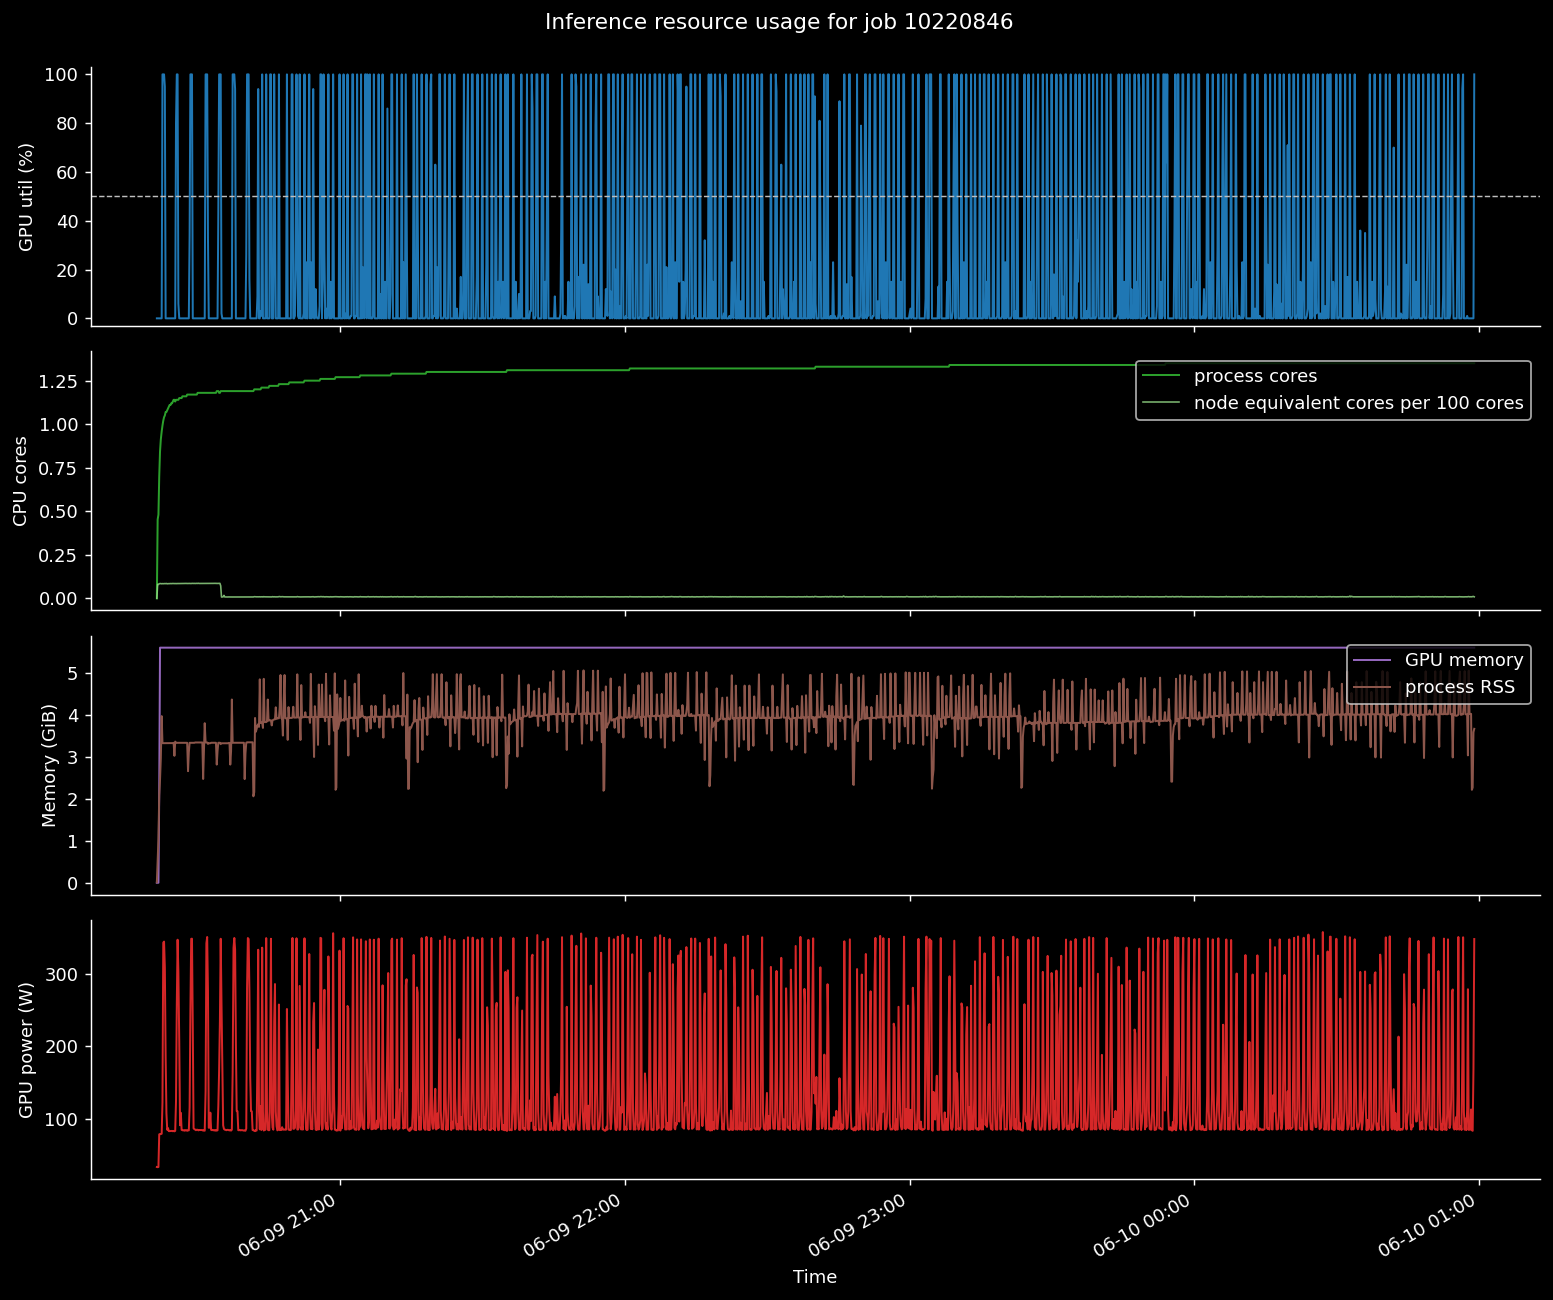

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(monitor_df["timestamp"], monitor_df["gpu_utilization_gpu_pct"], color="#1f77b4", lw=1.1)
axes[0].set_ylabel("GPU util (%)")
axes[0].set_ylim(-3, 103)
axes[0].axhline(50, color="0.75", lw=0.8, ls="--")

axes[1].plot(monitor_df["timestamp"], monitor_df["process_cpu_pct"] / 100, label="process cores", color="#2ca02c", lw=1.1)
axes[1].plot(monitor_df["timestamp"], monitor_df["node_cpu_utilization_pct"] / 100, label="node equivalent cores per 100 cores", color="#98df8a", lw=0.9, alpha=0.8)
axes[1].set_ylabel("CPU cores")
axes[1].legend(loc="upper right")

axes[2].plot(monitor_df["timestamp"], monitor_df["gpu_memory_used_mib"] / 1024, label="GPU memory", color="#9467bd", lw=1.1)
axes[2].plot(monitor_df["timestamp"], monitor_df["process_rss_mib"] / 1024, label="process RSS", color="#8c564b", lw=1.1)
axes[2].set_ylabel("Memory (GiB)")
axes[2].legend(loc="upper right")

axes[3].plot(monitor_df["timestamp"], monitor_df["gpu_power_draw_w"], color="#d62728", lw=1.1)
axes[3].set_ylabel("GPU power (W)")
axes[3].set_xlabel("Time")

axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.autofmt_xdate()
fig.suptitle(f"Inference resource usage for job {JOB_ID}", y=0.995)
fig.tight_layout()


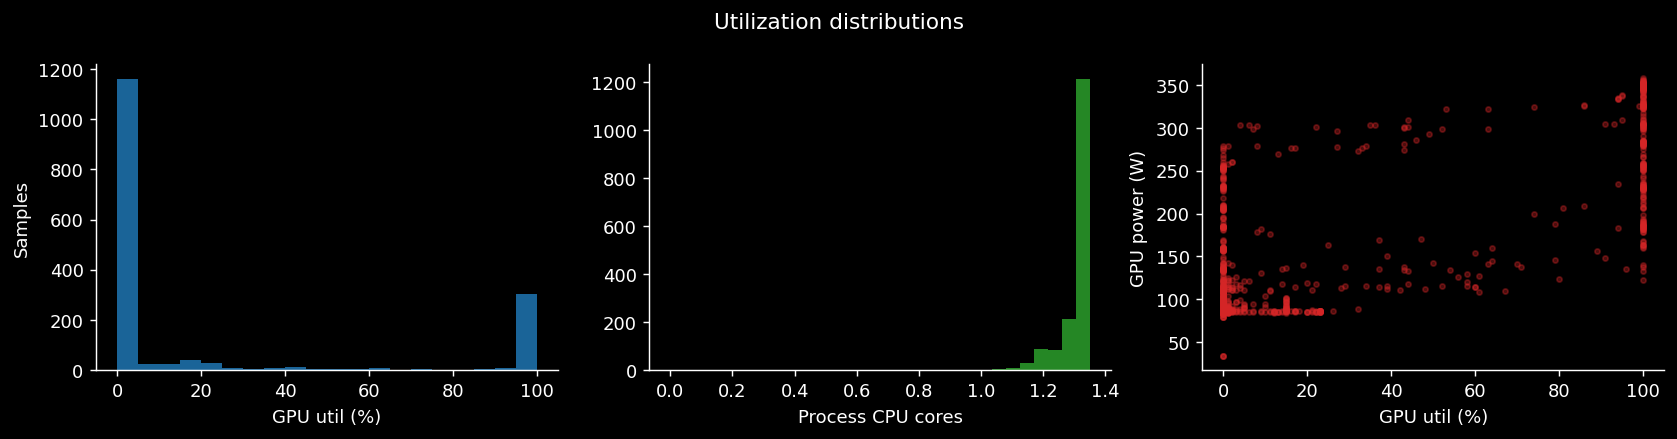

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

axes[0].hist(monitor_df["gpu_utilization_gpu_pct"].dropna(), bins=np.arange(0, 105, 5), color="#1f77b4", alpha=0.85)
axes[0].set_xlabel("GPU util (%)")
axes[0].set_ylabel("Samples")

axes[1].hist((monitor_df["process_cpu_pct"] / 100).dropna(), bins=30, color="#2ca02c", alpha=0.85)
axes[1].set_xlabel("Process CPU cores")

axes[2].scatter(monitor_df["gpu_utilization_gpu_pct"], monitor_df["gpu_power_draw_w"], s=8, alpha=0.35, color="#d62728")
axes[2].set_xlabel("GPU util (%)")
axes[2].set_ylabel("GPU power (W)")

fig.suptitle("Utilization distributions")
fig.tight_layout()


,epsilon,quantile,simulations,generation,duration_seconds
0,0.016545,0.873924,496,1,1036.53
1,0.016407,0.741439,436,2,918.95
2,0.016302,0.858779,580,3,1233.44
3,0.016196,0.822359,576,4,1235.30
4,0.016047,0.579036,628,5,1334.07
5,0.015927,0.394373,856,6,1818.58
6,0.015876,0.429512,468,7,992.96
7,0.015845,0.481012,536,8,1132.39
8,0.015805,0.345480,892,9,1895.64
9,0.015786,0.513301,1768,10,3797.44


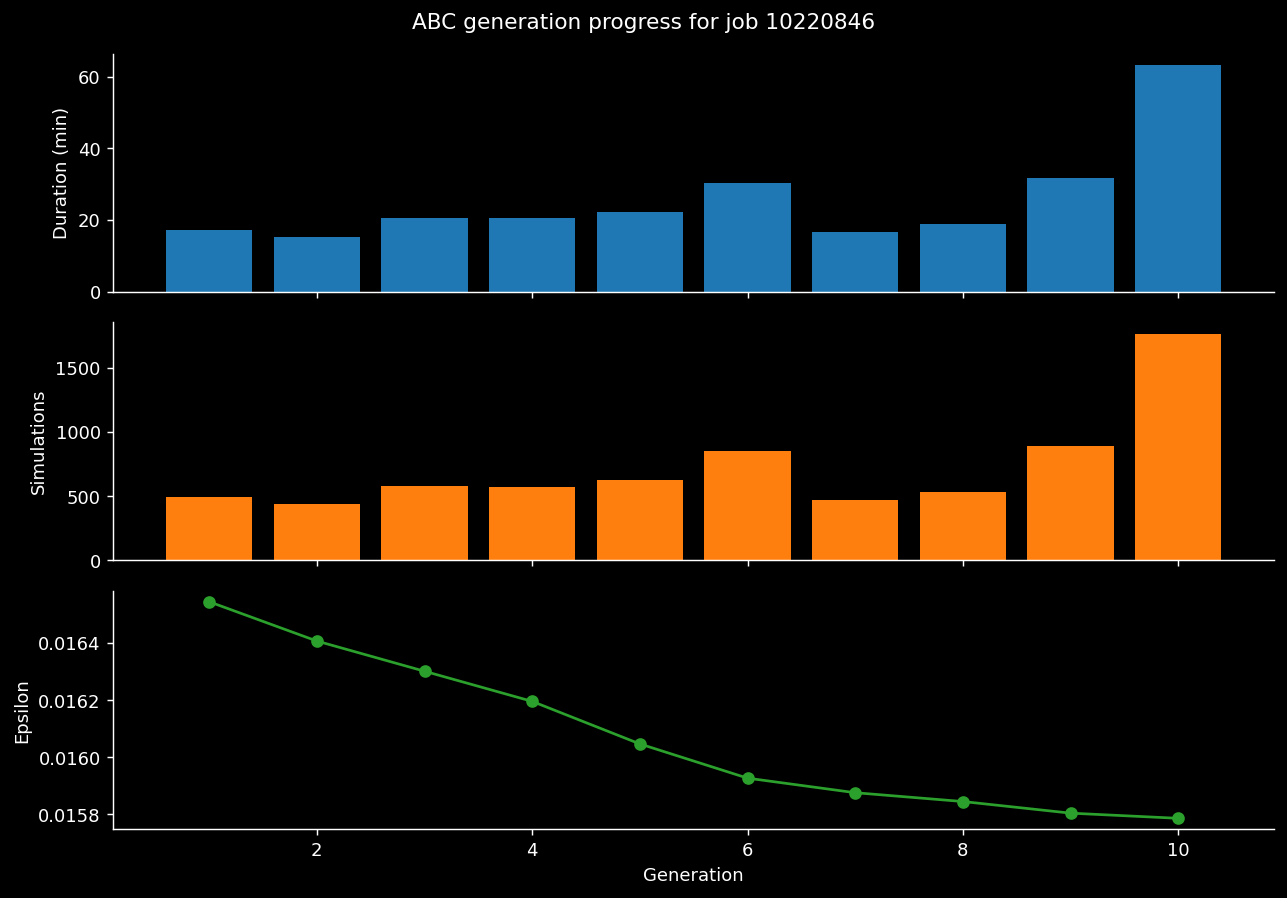

In [7]:
if generation_df.empty:
    print("No generation-level Slurm output was found or parsed.")
else:
    display(generation_df)
    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

    axes[0].bar(generation_df["generation"], generation_df["duration_seconds"] / 60, color="#1f77b4")
    axes[0].set_ylabel("Duration (min)")

    if "simulations" in generation_df:
        axes[1].bar(generation_df["generation"], generation_df["simulations"], color="#ff7f0e")
        axes[1].set_ylabel("Simulations")

    if "epsilon" in generation_df:
        axes[2].plot(generation_df["generation"], generation_df["epsilon"], marker="o", color="#2ca02c")
        axes[2].set_ylabel("Epsilon")

    axes[2].set_xlabel("Generation")
    fig.suptitle(f"ABC generation progress for job {JOB_ID}")
    fig.tight_layout()


## Reading the signals

- Low average GPU utilization with frequent 0% samples usually means the GPU is waiting for CPU-side simulation or Python scheduling.
- Low process CPU cores compared with requested Slurm CPUs means the job is not saturating the CPU allocation.
- Low GPU memory usage means larger `abc.simulation_batch_size` may be possible.
- If generation duration rises while GPU utilization remains low, later ABC generations are likely spending more time proposing/simulating rejected particles rather than encoding on GPU.